# Phase 3.2 - LLM-Assisted Hybrid Dynamic Policy

Notebook này triển khai Level 5 trong khung đánh giá 5 mức.
Comparator chính là tuned Level 4 từ Phase 3.1b. Level 5 kết hợp LightGBM risk score với MiniLM embedding thông qua similarity threshold adjustment hoặc hybrid score threshold.

Không fine-tune LLM, không dùng API LLM trên toàn bộ dataset, không tune trên test. Nếu local thiếu sentence-transformers, fallback TF-IDF/SVD chỉ dùng smoke test; claim LLM cuối cùng chỉ hợp lệ khi metadata ghi embedding_backend_used = minilm.


## 0. Run Contract

Chạy sau notebook 02, 04, và 04b với cùng RUN_MODE. Input chính: baseline_scores, phase31b candidate metrics, selected policies, candidate thresholds, five-level tuned comparison, và raw IEEE-CIS CSVs. Output chính: phase32 hybrid metrics, selected policy, similarity features, leakage audit, disagreement cases, comparison Level 5, metadata, và figures.


In [3]:
from pathlib import Path
import gc
import json
import os
import subprocess
import sys
import warnings

import numpy as np
import pandas as pd

import matplotlib
if "COLAB_RELEASE_TAG" not in os.environ:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.special import expit, logit
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import average_precision_score, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.preprocessing import normalize

try:
    from IPython.display import display
except Exception:
    display = print

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 220)

SEED = 42
np.random.seed(SEED)

RUN_MODE = "sample_100k"  # "smoke", "sample_100k", "sample_200k", "sample_300k", or "full"
RUN_MODE_SAMPLE_ROWS = {"smoke": 10_000, "sample_100k": 100_000, "sample_200k": 200_000, "sample_300k": 300_000, "full": None}
if RUN_MODE not in RUN_MODE_SAMPLE_ROWS:
    raise ValueError(f"Unsupported RUN_MODE={RUN_MODE!r}")

RUN_OUTPUT_TAG = RUN_MODE
SAMPLE_ROWS = RUN_MODE_SAMPLE_ROWS[RUN_MODE]
SAMPLE_ROWS_LABEL = SAMPLE_ROWS if SAMPLE_ROWS is not None else "full"

SELECTED_RISK_MODEL = "lightgbm_balanced"
MODEL_FALLBACK_ORDER = ["lightgbm_balanced", "xgboost_magic_style", "lightgbm_magic_style", "xgboost_scale_pos_weight", "random_forest_balanced", "logistic_regression_balanced"]
LEVEL4_COMPARATOR_SELECTOR = "level4_tuned_guarded_selector"

COST_CONFIGS = {"Cost-A": {"alpha": 0.05, "beta": 1.0}, "Cost-B": {"alpha": 0.10, "beta": 2.0}, "Cost-C": {"alpha": 0.20, "beta": 5.0}}
GAMMA_GRID = [-0.20, -0.10, -0.05, 0.00, 0.05, 0.10, 0.20]
W_GRID = [-2.0, -1.0, -0.5, 0.0, 0.5, 1.0, 2.0]
THRESHOLD_GRID = np.unique(np.concatenate([np.linspace(0.0, 1.0, 201), np.array([0.001, 0.005, 0.01, 0.02, 0.03, 0.05, 0.10, 0.20, 0.30, 0.40, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99])]))

EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
AUTO_INSTALL_SENTENCE_TRANSFORMERS = "COLAB_RELEASE_TAG" in os.environ
EMBEDDING_BATCH_SIZE = 32 if RUN_MODE.startswith("sample_") else (64 if RUN_MODE == "smoke" else 128)
TEXT_SERIALIZE_CHUNK = 50_000
TFIDF_MAX_FEATURES = 4096
TFIDF_SVD_COMPONENTS = 64

IN_COLAB = "COLAB_RELEASE_TAG" in os.environ
DEFAULT_COLAB_PROJECT_ROOT = "/content/drive/MyDrive/BaoMatCuoiKy/LLM-Assisted_Cost-Sensitive" if IN_COLAB else ""
PROJECT_ROOT_OVERRIDE = os.environ.get("PROJECT_ROOT_OVERRIDE", DEFAULT_COLAB_PROJECT_ROOT).strip()

if IN_COLAB:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception as exc:
        print(f"Google Drive mount skipped/failed: {exc}")

def looks_like_project_root(path: Path) -> bool:
    return (path / "notebooks").exists() and (path / "results").exists() and (path / "data").exists()

def find_project_root() -> Path:
    candidates = []
    if PROJECT_ROOT_OVERRIDE:
        candidates.append(Path(PROJECT_ROOT_OVERRIDE))
    cwd = Path.cwd()
    candidates.extend([cwd, cwd.parent, cwd / "LLM-Assisted_Cost-Sensitive", Path("/content/LLM-Assisted_Cost-Sensitive"), Path("/content/drive/MyDrive/BaoMatCuoiKy/LLM-Assisted_Cost-Sensitive"), Path("/content/drive/MyDrive/LLM-Assisted_Cost-Sensitive")])
    seen = set()
    for candidate in candidates:
        candidate = candidate.expanduser().resolve()
        if candidate in seen:
            continue
        seen.add(candidate)
        if candidate.exists() and looks_like_project_root(candidate):
            return candidate
    checked = "\n".join(f"- {p}" for p in candidates)
    raise FileNotFoundError("Cannot find project root. Set PROJECT_ROOT_OVERRIDE.\nChecked:\n" + checked)

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RAW_DIR = PROJECT_ROOT / "data" / "raw"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
EMBEDDINGS_DIR = PROJECT_ROOT / "artifacts" / "embeddings"
for directory in [RESULTS_DIR, FIGURES_DIR, EMBEDDINGS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

PATHS = {
    "train_transaction": RAW_DIR / "train_transaction.csv",
    "train_identity": RAW_DIR / "train_identity.csv",
    "baseline_scores": RESULTS_DIR / f"baseline_scores_{RUN_OUTPUT_TAG}.csv",
    "phase31b_candidate_metrics": RESULTS_DIR / f"phase31b_candidate_metrics_{RUN_OUTPUT_TAG}.csv",
    "phase31b_selected_policies": RESULTS_DIR / f"phase31b_selected_policies_{RUN_OUTPUT_TAG}.csv",
    "phase31b_candidate_thresholds": RESULTS_DIR / f"phase31b_candidate_thresholds_{RUN_OUTPUT_TAG}.csv",
    "five_level_tuned": RESULTS_DIR / f"five_level_comparison_tuned_{RUN_OUTPUT_TAG}.csv",
}
print(f"Project root: {PROJECT_ROOT}")
print(f"RUN_MODE={RUN_MODE} | SCORE_PATH={PATHS['baseline_scores']}")
print("Phase 3.2 scope: Level 5 LLM-assisted hybrid dynamic policy.")


Mounted at /content/drive
Project root: /content/drive/MyDrive/BaoMatCuoiKy/LLM-Assisted_Cost-Sensitive
RUN_MODE=sample_100k | SCORE_PATH=/content/drive/MyDrive/BaoMatCuoiKy/LLM-Assisted_Cost-Sensitive/results/baseline_scores_sample_100k.csv
Phase 3.2 scope: Level 5 LLM-assisted hybrid dynamic policy.


## 1. Load Phase 2 and Phase 3.1b Artifacts


In [4]:
REQUIRED_SCORE_COLUMNS = {"run_mode", "sample_rows", "split", "TransactionID", "isFraud", "TransactionAmt", "model", "score"}
REQUIRED_INPUTS = ["baseline_scores", "phase31b_candidate_metrics", "phase31b_selected_policies", "phase31b_candidate_thresholds", "five_level_tuned"]
missing_inputs = [name for name in REQUIRED_INPUTS if not PATHS[name].exists()]
if missing_inputs:
    available = sorted(str(p.relative_to(PROJECT_ROOT)) for p in RESULTS_DIR.glob("*.csv"))
    raise FileNotFoundError("Missing Phase 3.2 input files:\n" + "\n".join(f"- {name}: {PATHS[name]}" for name in missing_inputs) + "\n\nRun notebooks 02, 04, and 04b first with the same RUN_MODE.\n\nAvailable CSV files under results/:\n" + "\n".join(f"  - {p}" for p in available[:80]))

scores_df = pd.read_csv(PATHS["baseline_scores"])
phase31b_metrics_df = pd.read_csv(PATHS["phase31b_candidate_metrics"])
phase31b_selected_df = pd.read_csv(PATHS["phase31b_selected_policies"])
phase31b_thresholds_df = pd.read_csv(PATHS["phase31b_candidate_thresholds"])
five_level_tuned_df = pd.read_csv(PATHS["five_level_tuned"])

missing_columns = sorted(REQUIRED_SCORE_COLUMNS - set(scores_df.columns))
if missing_columns:
    raise ValueError(f"baseline_scores is missing columns: {missing_columns}")

for name, df in [("scores_df", scores_df), ("phase31b_metrics_df", phase31b_metrics_df), ("phase31b_selected_df", phase31b_selected_df), ("phase31b_thresholds_df", phase31b_thresholds_df), ("five_level_tuned_df", five_level_tuned_df)]:
    if "run_mode" in df.columns:
        found_modes = set(df["run_mode"].astype(str).dropna())
        if found_modes and not found_modes.issubset({RUN_MODE}):
            raise ValueError(f"{name} RUN_MODE mismatch. Expected {RUN_MODE}, found {sorted(found_modes)}")

scores_df["split"] = scores_df["split"].astype(str)
scores_df["model"] = scores_df["model"].astype(str)
scores_df["TransactionID"] = scores_df["TransactionID"].astype(str)
scores_df["isFraud"] = scores_df["isFraud"].astype(int)
scores_df["TransactionAmt"] = scores_df["TransactionAmt"].fillna(0).astype(float)
scores_df["score"] = scores_df["score"].astype(float)

available_models = sorted(scores_df["model"].unique())
if SELECTED_RISK_MODEL not in available_models:
    fallback = next((name for name in MODEL_FALLBACK_ORDER if name in available_models), None)
    if fallback is None:
        raise ValueError(f"No supported risk model found. Available models: {available_models}")
    print(f"Selected model {SELECTED_RISK_MODEL!r} not found. Falling back to {fallback!r}.")
    SELECTED_RISK_MODEL = fallback

policy_scores = scores_df[scores_df["model"].eq(SELECTED_RISK_MODEL)].copy()
if not {"validation", "test"}.issubset(set(policy_scores["split"])):
    raise ValueError(f"Selected model {SELECTED_RISK_MODEL!r} must have validation and test rows. Found: {sorted(policy_scores['split'].unique())}")
if policy_scores.duplicated(["split", "TransactionID"]).any():
    dupes = policy_scores[policy_scores.duplicated(["split", "TransactionID"], keep=False)]
    raise ValueError(f"Duplicate score rows detected. Example:\n{dupes.head()}")

validation_scores_df = policy_scores[policy_scores["split"].eq("validation")].reset_index(drop=True)
test_scores_df = policy_scores[policy_scores["split"].eq("test")].reset_index(drop=True)

print(f"Selected risk model: {SELECTED_RISK_MODEL}")
print(f"Validation rows: {len(validation_scores_df):,} | Test rows: {len(test_scores_df):,}")
display(phase31b_selected_df[["selector", "cost_config", "selected_candidate_policy", "selected_candidate_id", "recall_fraud", "precision_fraud", "total_cost", "cost_saving_vs_approve_all"]].sort_values(["selector", "cost_config"]))


Selected risk model: lightgbm_balanced
Validation rows: 15,000 | Test rows: 15,000


,selector,cost_config,selected_candidate_policy,selected_candidate_id,recall_fraud,precision_fraud,total_cost,cost_saving_vs_approve_all
0,level4_tuned_best_cost_selector,Cost-A,level4_bin_strategy_grid,bin_strategy_quantile_60_85_97_cost_a,0.742706,0.278607,19968.487743,25203.599138
1,level4_tuned_best_cost_selector,Cost-B,level4_bin_strategy_grid,bin_strategy_quantile_60_85_97_cost_b,0.742706,0.278607,39936.975486,50407.198276
2,level4_tuned_best_cost_selector,Cost-C,level4_bin_strategy_grid,bin_strategy_quantile_60_85_97_cost_c,0.814324,0.182196,93330.006170,132530.428236
3,level4_tuned_guarded_selector,Cost-A,level4_shrunk_amount_bin_threshold,shrunk_cost_a_lambda_0_75,0.726790,0.302428,20635.042850,24537.044032
4,level4_tuned_guarded_selector,Cost-B,level4_shrunk_amount_bin_threshold,shrunk_cost_b_lambda_0_75,0.726790,0.302428,41270.085699,49074.088063
5,level4_tuned_guarded_selector,Cost-C,level4_bin_strategy_grid,bin_strategy_quantile_60_85_97_cost_c,0.814324,0.182196,93330.006170,132530.428236


## 2. Metrics and Tuned Level 4 Helpers


In [5]:
def safe_average_precision(y_true, scores):
    return float(average_precision_score(y_true, scores)) if len(np.unique(y_true)) >= 2 else np.nan

def safe_roc_auc(y_true, scores):
    return float(roc_auc_score(y_true, scores)) if len(np.unique(y_true)) >= 2 else np.nan

def cost_components(y_true, y_pred, amount, alpha, beta):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    amount = np.asarray(amount, dtype=float)
    fn_mask = (y_true == 1) & (y_pred == 0)
    fp_mask = (y_true == 0) & (y_pred == 1)
    fn_cost = float(np.sum(amount[fn_mask] * beta))
    fp_cost = float(np.sum(amount[fp_mask] * alpha))
    return fn_cost, fp_cost, fn_cost + fp_cost

def row_cost(y_true, y_pred, amount, alpha, beta):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    amount = np.asarray(amount, dtype=float)
    return ((y_true == 1) & (y_pred == 0)).astype(float) * amount * beta + ((y_true == 0) & (y_pred == 1)).astype(float) * amount * alpha

def approve_all_cost(y_true, amount, beta):
    y_true = np.asarray(y_true, dtype=int)
    amount = np.asarray(amount, dtype=float)
    return float(np.sum(amount[y_true == 1] * beta))

def evaluate_predictions(policy_name, level, split_name, cost_config_name, y_true, scores, y_pred, amount, alpha, beta, extra=None):
    y_true = np.asarray(y_true, dtype=int)
    scores = np.asarray(scores, dtype=float)
    y_pred = np.asarray(y_pred, dtype=int)
    amount = np.asarray(amount, dtype=float)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    fn_cost, fp_cost, total_cost = cost_components(y_true, y_pred, amount, alpha, beta)
    reference_cost = approve_all_cost(y_true, amount, beta)
    row = {
        "run_mode": RUN_MODE, "sample_rows": SAMPLE_ROWS_LABEL, "level": level, "policy": policy_name,
        "source_model": SELECTED_RISK_MODEL, "split": split_name, "cost_config": cost_config_name,
        "alpha": alpha, "beta": beta, "pr_auc": safe_average_precision(y_true, scores), "roc_auc": safe_roc_auc(y_true, scores),
        "recall_fraud": float(recall_score(y_true, y_pred, zero_division=0)),
        "precision_fraud": float(precision_score(y_true, y_pred, zero_division=0)),
        "f1_fraud": float(f1_score(y_true, y_pred, zero_division=0)),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        "fn_cost": fn_cost, "fp_cost": fp_cost, "total_cost": total_cost,
        "approve_all_cost": reference_cost,
        "cost_saving_vs_approve_all": reference_cost - total_cost,
        "cost_saving_pct_vs_approve_all": (reference_cost - total_cost) / reference_cost if reference_cost else np.nan,
    }
    if extra:
        row.update(extra)
    return row

def rank_metric_rows(df):
    out = df.copy()
    priority = {"level5_embedding_similarity_threshold_adjustment": 1, "level5_hybrid_score_threshold": 2, "level5_meta_policy_small": 3}
    out["policy_priority"] = out["policy"].map(priority).fillna(99)
    return out.sort_values(["total_cost", "fp_cost", "recall_fraud", "precision_fraud", "policy_priority"], ascending=[True, True, False, False, True])

def safe_id(*parts):
    return "_".join(str(p).lower().replace(".", "_").replace("-", "_").replace(" ", "_") for p in parts)

def assign_bins(amounts, threshold_table):
    table = threshold_table.sort_values("bin_order").reset_index(drop=True)
    edges = list(table["bin_lower_bound"].astype(float)) + [float(table["bin_upper_bound"].iloc[-1])]
    labels = table["amount_bin"].astype(str).tolist()
    bins = pd.cut(
        pd.Series(amounts, dtype="float64"),
        bins=edges,
        labels=labels,
        include_lowest=True,
        right=True,
    ).astype(str).to_numpy()
    if pd.isna(bins).any() or np.any(bins == "nan"):
        raise ValueError("Some rows did not map to an amount bin.")
    return bins

def threshold_table_for_candidate(candidate_id, cost_config_name):
    table = phase31b_thresholds_df[phase31b_thresholds_df["candidate_id"].astype(str).eq(str(candidate_id)) & phase31b_thresholds_df["cost_config"].eq(cost_config_name)].copy()
    if table.empty:
        raise ValueError(f"No threshold table for candidate_id={candidate_id}, cost={cost_config_name}")
    return table.sort_values(["bin_lower_bound", "bin_upper_bound"]).reset_index(drop=True)

def selected_level4_row(cost_config_name, selector=LEVEL4_COMPARATOR_SELECTOR):
    rows = phase31b_selected_df[phase31b_selected_df["selector"].astype(str).eq(selector) & phase31b_selected_df["cost_config"].eq(cost_config_name)].copy()
    if rows.empty and selector != "level4_tuned_best_cost_selector":
        rows = phase31b_selected_df[phase31b_selected_df["selector"].astype(str).eq("level4_tuned_best_cost_selector") & phase31b_selected_df["cost_config"].eq(cost_config_name)].copy()
    if rows.empty:
        raise ValueError(f"No selected Level 4 row found for {cost_config_name}")
    return rows.iloc[0]

def level4_thresholds_for_frame(frame, threshold_table):
    if set(threshold_table["amount_bin"].astype(str)) == {"all"}:
        bins = np.array(["all"] * len(frame), dtype=object)
        thresholds = np.full(len(frame), float(threshold_table["threshold"].iloc[0]), dtype=float)
        return thresholds, bins
    bins = assign_bins(frame["TransactionAmt"].to_numpy(dtype=float), threshold_table)
    lookup = dict(zip(threshold_table["amount_bin"].astype(str), threshold_table["threshold"].astype(float)))
    thresholds = pd.Series(bins).map(lookup).astype(float).to_numpy()
    return thresholds, bins

def apply_level4_thresholds(frame, threshold_table):
    thresholds, bins = level4_thresholds_for_frame(frame, threshold_table)
    pred = (frame["score"].to_numpy(dtype=float) >= thresholds).astype(int)
    return pred, thresholds, bins

for cost_name in COST_CONFIGS:
    row = selected_level4_row(cost_name)
    table = threshold_table_for_candidate(row["selected_candidate_id"], cost_name)
    assert not table.empty
print("Level 4 comparator selector:", LEVEL4_COMPARATOR_SELECTOR)


Level 4 comparator selector: level4_tuned_guarded_selector


## 3. Load Raw IEEE-CIS Rows and Align Splits


In [6]:
TEXT_FEATURE_COLUMNS = ["TransactionAmt", "ProductCD", "card1", "card2", "card3", "card4", "card5", "card6", "addr1", "addr2", "P_emaildomain", "R_emaildomain", "DeviceType", "DeviceInfo", "id_12", "id_15", "id_30", "id_31", "id_34"]
TRANSACTION_TEXT_COLUMNS = ["TransactionID", "TransactionDT", "isFraud", "TransactionAmt", "ProductCD", "card1", "card2", "card3", "card4", "card5", "card6", "addr1", "addr2", "P_emaildomain", "R_emaildomain"]
IDENTITY_TEXT_COLUMNS = ["TransactionID", "DeviceType", "DeviceInfo", "id_12", "id_15", "id_30", "id_31", "id_34"]

missing_raw = [str(PATHS[name]) for name in ["train_transaction", "train_identity"] if not PATHS[name].exists()]
if missing_raw:
    raise FileNotFoundError("Missing raw IEEE-CIS CSV files:\n" + "\n".join(missing_raw))

print("Loading raw transaction rows for neutral text serialization...")
transaction_df = pd.read_csv(PATHS["train_transaction"], usecols=lambda c: c in set(TRANSACTION_TEXT_COLUMNS), nrows=SAMPLE_ROWS)
identity_df = pd.read_csv(PATHS["train_identity"], usecols=lambda c: c in set(IDENTITY_TEXT_COLUMNS))
raw_joined_df = transaction_df.merge(identity_df, on="TransactionID", how="left")
assert len(raw_joined_df) == len(transaction_df), "Left join changed transaction row count."
raw_joined_df = raw_joined_df.sort_values("TransactionDT", kind="mergesort").reset_index(drop=True)
raw_joined_df["TransactionID"] = raw_joined_df["TransactionID"].astype(str)

n_total = len(raw_joined_df)
n_train = int(n_total * 0.70)
n_validation = int(n_total * 0.15)
train_raw_df = raw_joined_df.iloc[:n_train].copy()
validation_raw_df = raw_joined_df.iloc[n_train:n_train + n_validation].copy()
test_raw_df = raw_joined_df.iloc[n_train + n_validation:].copy()

def align_raw_to_scores(raw_split, score_split, split_name):
    raw_indexed = raw_split.set_index("TransactionID", drop=False)
    ids = score_split["TransactionID"].astype(str).tolist()
    missing = [tid for tid in ids if tid not in raw_indexed.index]
    if missing:
        raise ValueError(f"Raw {split_name} split is missing score TransactionIDs. Examples: {missing[:5]}")
    aligned = raw_indexed.loc[ids].reset_index(drop=True)
    if aligned["TransactionID"].astype(str).tolist() != ids:
        raise AssertionError(f"{split_name} alignment failed.")
    if not np.array_equal(aligned["isFraud"].astype(int).to_numpy(), score_split["isFraud"].astype(int).to_numpy()):
        raise AssertionError(f"{split_name} labels differ between raw split and score file.")
    return aligned

validation_raw_df = align_raw_to_scores(validation_raw_df, validation_scores_df, "validation")
test_raw_df = align_raw_to_scores(test_raw_df, test_scores_df, "test")

split_summary = pd.DataFrame([
    {"split": "train", "rows": len(train_raw_df), "fraud_rate": train_raw_df["isFraud"].mean()},
    {"split": "validation", "rows": len(validation_raw_df), "fraud_rate": validation_raw_df["isFraud"].mean()},
    {"split": "test", "rows": len(test_raw_df), "fraud_rate": test_raw_df["isFraud"].mean()},
])
display(split_summary)
for leak_col in ["isFraud", "TransactionID", "TransactionDT"]:
    assert leak_col not in [c for c in TEXT_FEATURE_COLUMNS if c in train_raw_df.columns], f"Text feature leakage: {leak_col}"
del transaction_df, identity_df, raw_joined_df
gc.collect()


Loading raw transaction rows for neutral text serialization...


,split,rows,fraud_rate
0,train,70000,0.026843
1,validation,15000,0.025133
2,test,15000,0.020333


31

## 4. Neutral Table-to-Text and Leakage Audit


In [7]:
FORBIDDEN_TEXT_TOKENS = ["isfraud", "label", "target", "score", "prediction", "predict", "risk", "risky", "suspicious", "high risk", "low risk"]
PRODUCT_INTERP_TOKENS = ["product category", "goods category", "service category", "merchandise"]

def clean_value(value) -> str:
    if pd.isna(value):
        return "unknown"
    if isinstance(value, float):
        return str(int(value)) if value.is_integer() else f"{value:.4g}"
    text = str(value).strip()
    return text if text else "unknown"

def serialize_transaction(row: pd.Series) -> str:
    g = lambda c: clean_value(row[c]) if c in row.index else "unknown"
    return (f"A transaction with amount {g('TransactionAmt')}, product code {g('ProductCD')}, "
            f"card fields card1 {g('card1')}, card2 {g('card2')}, card3 {g('card3')}, card4 {g('card4')}, card5 {g('card5')}, card6 {g('card6')}, "
            f"address fields addr1 {g('addr1')} and addr2 {g('addr2')}, purchaser email domain {g('P_emaildomain')}, recipient email domain {g('R_emaildomain')}, "
            f"device type {g('DeviceType')}, device info {g('DeviceInfo')}, identity fields id_12 {g('id_12')}, id_15 {g('id_15')}, "
            f"operating system {g('id_30')}, browser {g('id_31')}, screen {g('id_34')}.")

def serialize_split_batched(df: pd.DataFrame, split_name: str, chunk_size: int = TEXT_SERIALIZE_CHUNK):
    columns = [c for c in TEXT_FEATURE_COLUMNS if c in df.columns]
    texts = []
    for start in range(0, len(df), chunk_size):
        end = min(start + chunk_size, len(df))
        chunk_texts = df.iloc[start:end][columns].apply(serialize_transaction, axis=1).tolist()
        texts.extend(chunk_texts)
        del chunk_texts
    print(f"Serialized {split_name}: {len(texts):,} texts")
    return texts

def audit_texts(texts, split_name):
    lower = [text.lower() for text in texts]
    forbidden = [tok for tok in FORBIDDEN_TEXT_TOKENS if any(tok in text for text in lower)]
    product_interp = [tok for tok in PRODUCT_INTERP_TOKENS if any(tok in text for text in lower)]
    return {"run_mode": RUN_MODE, "sample_rows": SAMPLE_ROWS_LABEL, "split": split_name, "rows": len(texts), "passed": bool(not forbidden and not product_interp), "forbidden_tokens_found": ";".join(forbidden), "product_interpretation_tokens_found": ";".join(product_interp), "text_policy": "neutral_ieee_cis_table_to_text_no_label_no_score_no_risk_words"}

train_texts = serialize_split_batched(train_raw_df, "train")
validation_texts = serialize_split_batched(validation_raw_df, "validation")
test_texts = serialize_split_batched(test_raw_df, "test")
text_audit_df = pd.DataFrame([audit_texts(train_texts, "train"), audit_texts(validation_texts, "validation"), audit_texts(test_texts, "test")])
if not text_audit_df["passed"].all():
    display(text_audit_df)
    raise AssertionError("Text leakage audit failed.")
TEXT_AUDIT_PATH = RESULTS_DIR / f"phase32_text_leakage_audit_{RUN_OUTPUT_TAG}.csv"
text_audit_df.to_csv(RESULTS_DIR / "phase32_text_leakage_audit.csv", index=False)
text_audit_df.to_csv(TEXT_AUDIT_PATH, index=False)
sample_text_df = pd.DataFrame({"run_mode": RUN_MODE, "split": "train", "TransactionID": train_raw_df["TransactionID"].head(5).astype(str).tolist(), "neutral_text": train_texts[:5]})
sample_text_df.to_csv(RESULTS_DIR / f"phase32_serialized_text_samples_{RUN_OUTPUT_TAG}.csv", index=False)
display(text_audit_df)
display(sample_text_df)


Serialized train: 70,000 texts
Serialized validation: 15,000 texts
Serialized test: 15,000 texts


,run_mode,sample_rows,split,rows,passed,forbidden_tokens_found,product_interpretation_tokens_found,text_policy
0,sample_100k,100000,train,70000,True,,,neutral_ieee_cis_table_to_text_no_label_no_sco...
1,sample_100k,100000,validation,15000,True,,,neutral_ieee_cis_table_to_text_no_label_no_sco...
2,sample_100k,100000,test,15000,True,,,neutral_ieee_cis_table_to_text_no_label_no_sco...


,run_mode,split,TransactionID,neutral_text
0,sample_100k,train,2987000,"A transaction with amount 68.5, product code W..."
1,sample_100k,train,2987001,"A transaction with amount 29, product code W, ..."
2,sample_100k,train,2987002,"A transaction with amount 59, product code W, ..."
3,sample_100k,train,2987003,"A transaction with amount 50, product code W, ..."
4,sample_100k,train,2987004,"A transaction with amount 50, product code H, ..."


## 5. Load or Create MiniLM Embeddings


In [8]:
def emb_file(prefix, split):
    return EMBEDDINGS_DIR / f"{prefix}_{split}.npy"

def emb_meta_file(prefix):
    return EMBEDDINGS_DIR / f"{prefix}_metadata.csv"

def emb_ids_file(prefix):
    return EMBEDDINGS_DIR / f"{prefix}_ids.csv"

def expected_split_ids():
    return {"train": train_raw_df["TransactionID"].astype(str).tolist(), "validation": validation_raw_df["TransactionID"].astype(str).tolist(), "test": test_raw_df["TransactionID"].astype(str).tolist()}

def cache_valid(prefix, expected_ids):
    if not all(emb_file(prefix, split).exists() for split in ["train", "validation", "test"]):
        return False
    if not emb_meta_file(prefix).exists() or not emb_ids_file(prefix).exists():
        return False
    try:
        meta = pd.read_csv(emb_meta_file(prefix))
        ids_df = pd.read_csv(emb_ids_file(prefix), dtype={"TransactionID": str})
        for split, ids in expected_ids.items():
            rows = meta[meta["split"].eq(split)]
            if rows.empty or int(rows["rows"].iloc[0]) != len(ids):
                return False
            cached_ids = ids_df[ids_df["split"].eq(split)]["TransactionID"].astype(str).tolist()
            if cached_ids != ids:
                return False
            arr = np.load(emb_file(prefix, split), mmap_mode="r")
            if arr.shape[0] != len(ids):
                return False
        return True
    except Exception as exc:
        print(f"Cache validation failed for {prefix}: {exc}")
        return False

def save_embedding_metadata(prefix, backend, model_name, arrays, expected_ids):
    meta_rows, id_rows = [], []
    for split, arr in arrays.items():
        meta_rows.append({"run_mode": RUN_MODE, "sample_rows": SAMPLE_ROWS_LABEL, "split": split, "rows": int(arr.shape[0]), "embedding_dim": int(arr.shape[1]), "backend": backend, "model_name": model_name, "prefix": prefix})
        id_rows.extend({"split": split, "TransactionID": tid} for tid in expected_ids[split])
    pd.DataFrame(meta_rows).to_csv(emb_meta_file(prefix), index=False)
    pd.DataFrame(id_rows).to_csv(emb_ids_file(prefix), index=False)

def try_import_sentence_transformer():
    try:
        from sentence_transformers import SentenceTransformer
        return SentenceTransformer
    except ImportError:
        if AUTO_INSTALL_SENTENCE_TRANSFORMERS:
            print("Installing sentence-transformers for Colab...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "sentence-transformers"])
            from sentence_transformers import SentenceTransformer
            return SentenceTransformer
        return None

def encode_minilm(text_map, prefix):
    SentenceTransformer = try_import_sentence_transformer()
    if SentenceTransformer is None:
        return None
    try:
        model = SentenceTransformer(EMBEDDING_MODEL_NAME)
        arrays = {}
        for split in ["train", "validation", "test"]:
            print(f"Encoding {split} with MiniLM ({len(text_map[split]):,} rows)...")
            arr = model.encode(text_map[split], batch_size=EMBEDDING_BATCH_SIZE, show_progress_bar=True, normalize_embeddings=True, convert_to_numpy=True).astype(np.float32)
            np.save(emb_file(prefix, split), arr)
            arrays[split] = arr
        save_embedding_metadata(prefix, "minilm", EMBEDDING_MODEL_NAME, arrays, expected_ids)
        return arrays
    except Exception as exc:
        print(f"MiniLM embedding failed; falling back to TF-IDF/SVD for smoke verification only: {exc}")
        return None

def encode_tfidf_fallback(text_map, prefix):
    print("Using TF-IDF + TruncatedSVD fallback. This is not valid for final LLM claim.")
    vectorizer = TfidfVectorizer(max_features=TFIDF_MAX_FEATURES, ngram_range=(1, 2), min_df=2)
    x_train = vectorizer.fit_transform(text_map["train"])
    n_components = min(TFIDF_SVD_COMPONENTS, x_train.shape[1] - 1, x_train.shape[0] - 1)
    svd = TruncatedSVD(n_components=n_components, random_state=SEED)
    arrays = {"train": svd.fit_transform(x_train).astype(np.float32), "validation": svd.transform(vectorizer.transform(text_map["validation"])).astype(np.float32), "test": svd.transform(vectorizer.transform(text_map["test"])).astype(np.float32)}
    for split, arr in arrays.items():
        arr = normalize(arr, norm="l2", axis=1).astype(np.float32)
        arrays[split] = arr
        np.save(emb_file(prefix, split), arr)
    save_embedding_metadata(prefix, "tfidf_svd_fallback", "TF-IDF + TruncatedSVD fallback", arrays, expected_ids)
    return arrays

def load_cached_arrays(prefix):
    return {split: np.load(emb_file(prefix, split)).astype(np.float32) for split in ["train", "validation", "test"]}

expected_ids = expected_split_ids()
minilm_prefix = f"phase32_{RUN_OUTPUT_TAG}_minilm"
fallback_prefix = f"phase32_{RUN_OUTPUT_TAG}_tfidf_svd_fallback"
embedding_prefix, embedding_backend = None, None

if cache_valid(minilm_prefix, expected_ids):
    print(f"Using cached MiniLM embeddings: {minilm_prefix}")
    embeddings = load_cached_arrays(minilm_prefix)
    embedding_prefix, embedding_backend = minilm_prefix, "minilm"
else:
    text_map = {"train": train_texts, "validation": validation_texts, "test": test_texts}
    embeddings = encode_minilm(text_map, minilm_prefix)
    if embeddings is not None:
        embedding_prefix, embedding_backend = minilm_prefix, "minilm"
    elif cache_valid(fallback_prefix, expected_ids):
        print(f"Using cached fallback embeddings: {fallback_prefix}")
        embeddings = load_cached_arrays(fallback_prefix)
        embedding_prefix, embedding_backend = fallback_prefix, "tfidf_svd_fallback"
    else:
        embeddings = encode_tfidf_fallback(text_map, fallback_prefix)
        embedding_prefix, embedding_backend = fallback_prefix, "tfidf_svd_fallback"

emb_train = normalize(embeddings["train"], norm="l2", axis=1).astype(np.float32)
emb_validation = normalize(embeddings["validation"], norm="l2", axis=1).astype(np.float32)
emb_test = normalize(embeddings["test"], norm="l2", axis=1).astype(np.float32)
assert emb_train.shape[0] == len(train_raw_df)
assert emb_validation.shape[0] == len(validation_scores_df)
assert emb_test.shape[0] == len(test_scores_df)
del train_texts, validation_texts, test_texts, embeddings
gc.collect()
print(f"Embedding backend used: {embedding_backend}")
print(f"Embedding prefix: {embedding_prefix}")
print(f"Embedding shapes: train={emb_train.shape}, validation={emb_validation.shape}, test={emb_test.shape}")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

Encoding validation with MiniLM (15,000 rows)...


Batches:   0%|          | 0/469 [00:00<?, ?it/s]

Encoding test with MiniLM (15,000 rows)...


Batches:   0%|          | 0/469 [00:00<?, ?it/s]

Embedding backend used: minilm
Embedding prefix: phase32_sample_100k_minilm
Embedding shapes: train=(70000, 384), validation=(15000, 384), test=(15000, 384)


## 6. Train-Only Prototypes and Similarity Features


In [9]:
y_train = train_raw_df["isFraud"].astype(int).to_numpy()
y_validation = validation_scores_df["isFraud"].astype(int).to_numpy()
y_test = test_scores_df["isFraud"].astype(int).to_numpy()
if y_train.sum() == 0 or (len(y_train) - y_train.sum()) == 0:
    raise ValueError("Train split must contain both fraud and legitimate rows to compute prototypes.")

fraud_prototype = normalize(emb_train[y_train == 1].mean(axis=0, keepdims=True), norm="l2", axis=1).astype(np.float32)[0]
legit_prototype = normalize(emb_train[y_train == 0].mean(axis=0, keepdims=True), norm="l2", axis=1).astype(np.float32)[0]

def similarity_delta(emb):
    emb = normalize(emb, norm="l2", axis=1)
    return (emb @ fraud_prototype) - (emb @ legit_prototype)

sim_train = similarity_delta(emb_train)
sim_validation = similarity_delta(emb_validation)
sim_test = similarity_delta(emb_test)
sim_mean = float(np.mean(sim_train))
sim_std = float(np.std(sim_train)) if float(np.std(sim_train)) >= 1e-8 else 1.0
sim_train_z = (sim_train - sim_mean) / sim_std
sim_validation_z = (sim_validation - sim_mean) / sim_std
sim_test_z = (sim_test - sim_mean) / sim_std

similarity_features_df = pd.concat([
    pd.DataFrame({"run_mode": RUN_MODE, "sample_rows": SAMPLE_ROWS_LABEL, "split": "validation", "TransactionID": validation_scores_df["TransactionID"].astype(str), "embedding_backend_used": embedding_backend, "embedding_model_target": EMBEDDING_MODEL_NAME, "similarity_delta": sim_validation, "similarity_delta_z": sim_validation_z, "score": validation_scores_df["score"].to_numpy(dtype=float), "isFraud": y_validation, "TransactionAmt": validation_scores_df["TransactionAmt"].to_numpy(dtype=float)}),
    pd.DataFrame({"run_mode": RUN_MODE, "sample_rows": SAMPLE_ROWS_LABEL, "split": "test", "TransactionID": test_scores_df["TransactionID"].astype(str), "embedding_backend_used": embedding_backend, "embedding_model_target": EMBEDDING_MODEL_NAME, "similarity_delta": sim_test, "similarity_delta_z": sim_test_z, "score": test_scores_df["score"].to_numpy(dtype=float), "isFraud": y_test, "TransactionAmt": test_scores_df["TransactionAmt"].to_numpy(dtype=float)}),
], ignore_index=True)
SIMILARITY_PATH = RESULTS_DIR / f"phase32_similarity_features_{RUN_OUTPUT_TAG}.csv"
similarity_features_df.to_csv(RESULTS_DIR / "phase32_similarity_features.csv", index=False)
similarity_features_df.to_csv(SIMILARITY_PATH, index=False)
display(similarity_features_df.groupby(["split", "isFraud"])[["similarity_delta", "similarity_delta_z", "score"]].agg(["mean", "std", "count"]))


similarity_delta                  similarity_delta_z                      score                 
                               mean       std  count               mean       std  count      mean       std  count
split      isFraud                                                                                                 
test       0              -0.001448  0.005554  14695           0.183259  1.067306  14695  0.203658  0.184606  14695
           1               0.002907  0.007573    305           1.020012  1.455091    305  0.676334  0.306691    305
validation 0              -0.001689  0.005388  14623           0.136867  1.035354  14623  0.185115  0.174258  14623
           1               0.003247  0.007127    377           1.085352  1.369449    377  0.723641  0.280173    377

## 7. Candidate 1 - Embedding Similarity Threshold Adjustment


In [10]:
validation_df = validation_scores_df.copy()
test_df = test_scores_df.copy()
validation_df["similarity_delta_z"] = sim_validation_z
test_df["similarity_delta_z"] = sim_test_z
candidate_rows = []

def evaluate_threshold_adjustment(cost_config_name, alpha, beta, gamma, split_name, frame, sim_z):
    selected_l4 = selected_level4_row(cost_config_name)
    threshold_table = threshold_table_for_candidate(selected_l4["selected_candidate_id"], cost_config_name)
    base_thresholds, amount_bins = level4_thresholds_for_frame(frame, threshold_table)
    adjusted_thresholds = np.clip(base_thresholds - float(gamma) * np.asarray(sim_z, dtype=float), 0.0, 1.0)
    pred = (frame["score"].to_numpy(dtype=float) >= adjusted_thresholds).astype(int)
    candidate_id = safe_id("sim_adjust", cost_config_name, f"gamma_{gamma:.2f}")
    row = evaluate_predictions("level5_embedding_similarity_threshold_adjustment", 5, split_name, cost_config_name, frame["isFraud"].to_numpy(dtype=int), frame["score"].to_numpy(dtype=float), pred, frame["TransactionAmt"].to_numpy(dtype=float), alpha, beta, extra={"candidate_id": candidate_id, "candidate_family": "embedding_similarity_threshold_adjustment", "selection_pool": split_name == "validation", "selection_status": "candidate_validation" if split_name == "validation" else "candidate_test_after_validation_selection", "gamma": float(gamma), "w": np.nan, "threshold": np.nan, "threshold_min": float(np.min(adjusted_thresholds)), "threshold_max": float(np.max(adjusted_thresholds)), "amount_bin_count": int(pd.Series(amount_bins).nunique()), "uses_embedding": True, "embedding_backend": embedding_backend, "embedding_model_target": EMBEDDING_MODEL_NAME, "decision_score_type": "lightgbm_score_with_embedding_adjusted_level4_threshold", "level4_comparator_selector": LEVEL4_COMPARATOR_SELECTOR, "level4_selected_candidate_id": str(selected_l4["selected_candidate_id"])})
    return row, pred, adjusted_thresholds, amount_bins

for cost_config_name, cfg in COST_CONFIGS.items():
    alpha, beta = cfg["alpha"], cfg["beta"]
    for gamma in GAMMA_GRID:
        row, _, _, _ = evaluate_threshold_adjustment(cost_config_name, alpha, beta, gamma, "validation", validation_df, sim_validation_z)
        candidate_rows.append(row)

candidate_metrics_preview = pd.DataFrame(candidate_rows)
display(candidate_metrics_preview[["policy", "cost_config", "candidate_id", "gamma", "recall_fraud", "precision_fraud", "fp_cost", "total_cost"]].sort_values(["cost_config", "total_cost"]).head(12))


,policy,cost_config,candidate_id,gamma,recall_fraud,precision_fraud,fp_cost,total_cost
3,level5_embedding_similarity_threshold_adjustment,Cost-A,sim_adjust_cost_a_gamma_0_00,0.00,0.726790,0.302428,3125.316899,20635.042850
2,level5_embedding_similarity_threshold_adjustment,Cost-A,sim_adjust_cost_a_gamma__0_05,-0.05,0.689655,0.352782,2559.312550,21526.386512
4,level5_embedding_similarity_threshold_adjustment,Cost-A,sim_adjust_cost_a_gamma_0_05,0.05,0.740053,0.232306,3971.576497,22171.378445
5,level5_embedding_similarity_threshold_adjustment,Cost-A,sim_adjust_cost_a_gamma_0_10,0.10,0.740053,0.180583,4916.320896,23322.358844
1,level5_embedding_similarity_threshold_adjustment,Cost-A,sim_adjust_cost_a_gamma__0_10,-0.10,0.633952,0.370543,2480.876498,24261.556402
6,level5_embedding_similarity_threshold_adjustment,Cost-A,sim_adjust_cost_a_gamma_0_20,0.20,0.750663,0.127020,7370.536491,26083.945436
0,level5_embedding_similarity_threshold_adjustment,Cost-A,sim_adjust_cost_a_gamma__0_20,-0.20,0.413793,0.275618,2974.294899,29907.158779
10,level5_embedding_similarity_threshold_adjustment,Cost-B,sim_adjust_cost_b_gamma_0_00,0.00,0.726790,0.302428,6250.633799,41270.085699
9,level5_embedding_similarity_threshold_adjustment,Cost-B,sim_adjust_cost_b_gamma__0_05,-0.05,0.689655,0.352782,5118.625101,43052.773023
11,level5_embedding_similarity_threshold_adjustment,Cost-B,sim_adjust_cost_b_gamma_0_05,0.05,0.740053,0.232306,7943.152993,44342.756890


## 8. Candidate 2 - Hybrid Score Threshold


In [11]:
def clip_prob(scores):
    return np.clip(np.asarray(scores, dtype=float), 1e-6, 1 - 1e-6)

def hybrid_score(base_score, sim_z, w):
    return expit(logit(clip_prob(base_score)) + float(w) * np.asarray(sim_z, dtype=float))

def tune_threshold_for_score(frame, scores, alpha, beta):
    rows = []
    y = frame["isFraud"].to_numpy(dtype=int)
    amount = frame["TransactionAmt"].to_numpy(dtype=float)
    for threshold in THRESHOLD_GRID:
        pred = (scores >= threshold).astype(int)
        fn_cost, fp_cost, total_cost = cost_components(y, pred, amount, alpha, beta)
        rows.append({"threshold": float(threshold), "fn_cost": fn_cost, "fp_cost": fp_cost, "total_cost": total_cost, "recall_fraud": float(recall_score(y, pred, zero_division=0)), "precision_fraud": float(precision_score(y, pred, zero_division=0))})
    curve = pd.DataFrame(rows)
    return curve.sort_values(["total_cost", "fp_cost", "recall_fraud", "precision_fraud", "threshold"], ascending=[True, True, False, False, True]).iloc[0]

hybrid_score_tuning_rows = []
for cost_config_name, cfg in COST_CONFIGS.items():
    alpha, beta = cfg["alpha"], cfg["beta"]
    for w in W_GRID:
        val_hybrid_score = hybrid_score(validation_df["score"].to_numpy(dtype=float), sim_validation_z, w)
        selected_threshold = tune_threshold_for_score(validation_df, val_hybrid_score, alpha, beta)
        threshold = float(selected_threshold["threshold"])
        candidate_id = safe_id("hybrid_score", cost_config_name, f"w_{w:.2f}", f"thr_{threshold:.3f}")
        val_pred = (val_hybrid_score >= threshold).astype(int)
        row = evaluate_predictions("level5_hybrid_score_threshold", 5, "validation", cost_config_name, validation_df["isFraud"].to_numpy(dtype=int), val_hybrid_score, val_pred, validation_df["TransactionAmt"].to_numpy(dtype=float), alpha, beta, extra={"candidate_id": candidate_id, "candidate_family": "hybrid_score_threshold", "selection_pool": True, "selection_status": "candidate_validation", "gamma": np.nan, "w": float(w), "threshold": threshold, "threshold_min": threshold, "threshold_max": threshold, "amount_bin_count": 1, "uses_embedding": True, "embedding_backend": embedding_backend, "embedding_model_target": EMBEDDING_MODEL_NAME, "decision_score_type": "sigmoid_logit_lightgbm_plus_embedding_similarity", "level4_comparator_selector": LEVEL4_COMPARATOR_SELECTOR, "level4_selected_candidate_id": "not_applicable"})
        candidate_rows.append(row)
        hybrid_score_tuning_rows.append({"cost_config": cost_config_name, "w": float(w), "selected_threshold": threshold, "validation_total_cost": row["total_cost"], "validation_fp_cost": row["fp_cost"], "validation_recall_fraud": row["recall_fraud"], "validation_precision_fraud": row["precision_fraud"]})

hybrid_tuning_df = pd.DataFrame(hybrid_score_tuning_rows)
display(hybrid_tuning_df.sort_values(["cost_config", "validation_total_cost"]).head(12))


,cost_config,w,selected_threshold,validation_total_cost,validation_fp_cost,validation_recall_fraud,validation_precision_fraud
3,Cost-A,0.0,0.730,22423.988114,2195.424150,0.615385,0.483333
2,Cost-A,-0.5,0.575,22800.694960,5945.100996,0.681698,0.320050
4,Cost-A,0.5,0.715,23074.601150,4355.640194,0.679045,0.249513
5,Cost-A,1.0,0.680,24463.071437,7317.164490,0.721485,0.148472
1,Cost-A,-1.0,0.625,25122.437632,5152.877698,0.549072,0.322933
6,Cost-A,2.0,0.845,28434.093646,6648.694695,0.665782,0.121197
0,Cost-A,-2.0,0.730,33279.989876,5073.544997,0.281167,0.190991
10,Cost-B,0.0,0.730,44847.976228,4390.848300,0.615385,0.483333
9,Cost-B,-0.5,0.575,45601.389919,11890.201991,0.681698,0.320050
11,Cost-B,0.5,0.715,46149.202301,8711.280388,0.679045,0.249513


## 9. Validation-Only Level 5 Selection and Frozen Test Evaluation


In [12]:
candidate_metrics_validation_df = pd.DataFrame(candidate_rows)
selected_rows, test_rows = [], []
selected_test_actions, level4_test_actions = {}, {}

for cost_config_name, cfg in COST_CONFIGS.items():
    alpha, beta = cfg["alpha"], cfg["beta"]
    pool = candidate_metrics_validation_df[candidate_metrics_validation_df["split"].eq("validation") & candidate_metrics_validation_df["cost_config"].eq(cost_config_name) & candidate_metrics_validation_df["selection_pool"].astype(bool)].copy()
    selected = rank_metric_rows(pool).iloc[0].copy()
    selected_candidate_id = str(selected["candidate_id"])
    selected_policy = str(selected["policy"])
    selected_rows.append(selected.to_dict())

    if selected_policy == "level5_embedding_similarity_threshold_adjustment":
        gamma = float(selected["gamma"])
        test_row, test_pred, _, _ = evaluate_threshold_adjustment(cost_config_name, alpha, beta, gamma, "test", test_df, sim_test_z)
        test_row.update({"selected_candidate_id": selected_candidate_id, "selected_candidate_policy": selected_policy, "selected_validation_total_cost": float(selected["total_cost"]), "selected_validation_fp_cost": float(selected["fp_cost"]), "selection_status": "selected_test", "selector": "level5_validation_total_cost_selector"})
    elif selected_policy == "level5_hybrid_score_threshold":
        w = float(selected["w"])
        threshold = float(selected["threshold"])
        test_score = hybrid_score(test_df["score"].to_numpy(dtype=float), sim_test_z, w)
        test_pred = (test_score >= threshold).astype(int)
        test_row = evaluate_predictions("level5_hybrid_score_threshold", 5, "test", cost_config_name, test_df["isFraud"].to_numpy(dtype=int), test_score, test_pred, test_df["TransactionAmt"].to_numpy(dtype=float), alpha, beta, extra={"candidate_id": selected_candidate_id, "candidate_family": "hybrid_score_threshold", "selection_pool": False, "selection_status": "selected_test", "selector": "level5_validation_total_cost_selector", "gamma": np.nan, "w": w, "threshold": threshold, "threshold_min": threshold, "threshold_max": threshold, "amount_bin_count": 1, "uses_embedding": True, "embedding_backend": embedding_backend, "embedding_model_target": EMBEDDING_MODEL_NAME, "decision_score_type": "sigmoid_logit_lightgbm_plus_embedding_similarity", "level4_comparator_selector": LEVEL4_COMPARATOR_SELECTOR, "level4_selected_candidate_id": "not_applicable", "selected_candidate_id": selected_candidate_id, "selected_candidate_policy": selected_policy, "selected_validation_total_cost": float(selected["total_cost"]), "selected_validation_fp_cost": float(selected["fp_cost"])})
    else:
        raise ValueError(f"Unsupported selected policy: {selected_policy}")

    selected_test_actions[cost_config_name] = test_pred
    test_rows.append(test_row)
    l4_selected = selected_level4_row(cost_config_name)
    l4_table = threshold_table_for_candidate(l4_selected["selected_candidate_id"], cost_config_name)
    l4_pred, _, _ = apply_level4_thresholds(test_df, l4_table)
    level4_test_actions[cost_config_name] = l4_pred

selected_validation_df = pd.DataFrame(selected_rows)
selected_validation_df["selector"] = "level5_validation_total_cost_selector"
selected_validation_df["selected_candidate_id"] = selected_validation_df["candidate_id"].astype(str)
selected_validation_df["selected_candidate_policy"] = selected_validation_df["policy"].astype(str)
selected_validation_df["selected_validation_total_cost"] = selected_validation_df["total_cost"].astype(float)
selected_validation_df["selected_validation_fp_cost"] = selected_validation_df["fp_cost"].astype(float)
selected_validation_df["selection_status"] = "selected_validation"
selected_test_df = pd.DataFrame(test_rows)
phase32_selected_policy_df = pd.concat([selected_validation_df, selected_test_df], ignore_index=True, sort=False)

# Transparent test metrics for every validation-tuned candidate. Selection still uses validation only.
test_candidate_rows = []
for _, candidate in candidate_metrics_validation_df.iterrows():
    cost_config_name = candidate["cost_config"]
    cfg = COST_CONFIGS[cost_config_name]
    alpha, beta = cfg["alpha"], cfg["beta"]
    if candidate["policy"] == "level5_embedding_similarity_threshold_adjustment":
        row, _, _, _ = evaluate_threshold_adjustment(cost_config_name, alpha, beta, float(candidate["gamma"]), "test", test_df, sim_test_z)
    elif candidate["policy"] == "level5_hybrid_score_threshold":
        w = float(candidate["w"])
        threshold = float(candidate["threshold"])
        score = hybrid_score(test_df["score"].to_numpy(dtype=float), sim_test_z, w)
        pred = (score >= threshold).astype(int)
        row = evaluate_predictions("level5_hybrid_score_threshold", 5, "test", cost_config_name, test_df["isFraud"].to_numpy(dtype=int), score, pred, test_df["TransactionAmt"].to_numpy(dtype=float), alpha, beta, extra={"candidate_id": candidate["candidate_id"], "candidate_family": "hybrid_score_threshold", "selection_pool": False, "selection_status": "candidate_test_after_validation_tuning", "gamma": np.nan, "w": w, "threshold": threshold, "threshold_min": threshold, "threshold_max": threshold, "amount_bin_count": 1, "uses_embedding": True, "embedding_backend": embedding_backend, "embedding_model_target": EMBEDDING_MODEL_NAME, "decision_score_type": "sigmoid_logit_lightgbm_plus_embedding_similarity", "level4_comparator_selector": LEVEL4_COMPARATOR_SELECTOR, "level4_selected_candidate_id": "not_applicable"})
    else:
        continue
    test_candidate_rows.append(row)

phase32_candidate_metrics_df = pd.concat([candidate_metrics_validation_df, pd.DataFrame(test_candidate_rows), phase32_selected_policy_df], ignore_index=True, sort=False)
display(phase32_selected_policy_df[["split", "cost_config", "policy", "candidate_id", "gamma", "w", "threshold", "recall_fraud", "precision_fraud", "fp_cost", "total_cost", "cost_saving_vs_approve_all", "embedding_backend"]].sort_values(["split", "cost_config"]))


,split,cost_config,policy,candidate_id,gamma,w,threshold,recall_fraud,precision_fraud,fp_cost,total_cost,cost_saving_vs_approve_all,embedding_backend
3,test,Cost-A,level5_embedding_similarity_threshold_adjustment,sim_adjust_cost_a_gamma_0_00,0.0,NaN,NaN,0.645902,0.189060,3653.052798,20332.934777,17110.100182,minilm
4,test,Cost-B,level5_embedding_similarity_threshold_adjustment,sim_adjust_cost_b_gamma_0_00,0.0,NaN,NaN,0.645902,0.189060,7306.105596,40665.869555,34220.200364,minilm
5,test,Cost-C,level5_embedding_similarity_threshold_adjustment,sim_adjust_cost_c_gamma_0_00,0.0,NaN,NaN,0.711475,0.113791,35830.219749,99834.099649,87381.075147,minilm
0,validation,Cost-A,level5_embedding_similarity_threshold_adjustment,sim_adjust_cost_a_gamma_0_00,0.0,NaN,NaN,0.726790,0.302428,3125.316899,20635.042850,24537.044032,minilm
1,validation,Cost-B,level5_embedding_similarity_threshold_adjustment,sim_adjust_cost_b_gamma_0_00,0.0,NaN,NaN,0.726790,0.302428,6250.633799,41270.085699,49074.088063,minilm
2,validation,Cost-C,level5_embedding_similarity_threshold_adjustment,sim_adjust_cost_c_gamma_0_00,0.0,NaN,NaN,0.814324,0.182196,33608.771143,93330.006170,132530.428236,minilm


## 10. Compare Level 5 Against Tuned Level 4


In [13]:
level5_test_for_comparison = selected_test_df.copy()
level5_test_for_comparison["model"] = level5_test_for_comparison["policy"]
level5_test_for_comparison["status"] = "complete_phase32"
level5_test_for_comparison["level_label"] = "Level 5 - LLM-assisted hybrid dynamic policy"
level5_test_for_comparison["algorithm"] = "lightgbm_score_plus_embedding_similarity_policy"
level5_test_for_comparison["exploration"] = "none"
level5_test_for_comparison["uses_embedding"] = True
level5_test_for_comparison["embedding_backend"] = embedding_backend
base_comparison_df = five_level_tuned_df[~five_level_tuned_df["policy"].astype(str).eq("level5_llm_hybrid_policy_pending")].copy()
comparison_level5_df = pd.concat([base_comparison_df, level5_test_for_comparison], ignore_index=True, sort=False)
comparison_view = comparison_level5_df[comparison_level5_df["split"].astype(str).eq("test") & comparison_level5_df["cost_config"].isin(COST_CONFIGS.keys())].copy()
display(comparison_view[["level", "policy", "model", "cost_config", "recall_fraud", "precision_fraud", "f1_fraud", "fn_cost", "fp_cost", "total_cost", "cost_saving_vs_approve_all", "embedding_backend"]].sort_values(["cost_config", "level", "total_cost"]))

level4_guarded_test = phase31b_metrics_df[phase31b_metrics_df["split"].astype(str).eq("test") & phase31b_metrics_df["policy"].astype(str).eq(LEVEL4_COMPARATOR_SELECTOR)].copy()
level5_test = selected_test_df.copy()
summary_compare = level5_test.merge(level4_guarded_test[["cost_config", "total_cost", "cost_saving_vs_approve_all", "recall_fraud", "precision_fraud"]], on="cost_config", how="left", suffixes=("_level5", "_level4"))
summary_compare["total_cost_delta_level5_minus_level4"] = summary_compare["total_cost_level5"] - summary_compare["total_cost_level4"]
summary_compare["saving_delta_level5_minus_level4"] = summary_compare["cost_saving_vs_approve_all_level5"] - summary_compare["cost_saving_vs_approve_all_level4"]
display(summary_compare[["cost_config", "policy", "embedding_backend", "total_cost_level4", "total_cost_level5", "total_cost_delta_level5_minus_level4", "saving_delta_level5_minus_level4", "recall_fraud_level4", "recall_fraud_level5", "precision_fraud_level4", "precision_fraud_level5"]])


,level,policy,model,cost_config,recall_fraud,precision_fraud,f1_fraud,fn_cost,fp_cost,total_cost,cost_saving_vs_approve_all,embedding_backend
0,0,approve_all,approve_all,Cost-A,0.000000,0.000000,0.000000,37443.034959,0.000000,37443.034959,0.000000,NaN
1,1,logistic_regression_balanced,logistic_regression_balanced,Cost-A,0.400000,0.239686,0.299754,26982.424971,4041.330498,31023.755469,6419.279491,NaN
2,2,lightgbm_balanced,lightgbm_balanced,Cost-A,0.567213,0.335271,0.421437,18039.317970,2159.069448,20198.387418,17244.647541,NaN
3,2,xgboost_magic_style,xgboost_magic_style,Cost-A,0.632787,0.143601,0.234081,16389.751976,8212.302143,24602.054119,12840.980840,NaN
12,3,level3_global_cost_threshold,level3_global_cost_threshold,Cost-A,0.567213,0.335271,0.421437,18039.317970,2159.069448,20198.387418,17244.647541,NaN
27,4,level4_tuned_best_cost_selector,level4_tuned_best_cost_selector,Cost-A,0.659016,0.179304,0.281907,14006.881979,6041.124241,20048.006220,17395.028739,NaN
30,4,level4_tuned_guarded_selector,level4_tuned_guarded_selector,Cost-A,0.645902,0.189060,0.292502,16679.881979,3653.052798,20332.934777,17110.100182,NaN
15,4,level4_amount_bin_dynamic_threshold,level4_amount_bin_dynamic_threshold,Cost-A,0.655738,0.148368,0.241984,16625.663980,4402.340947,21028.004927,16415.030032,NaN
33,5,level5_embedding_similarity_threshold_adjustment,level5_embedding_similarity_threshold_adjustment,Cost-A,0.645902,0.189060,0.292502,16679.881979,3653.052798,20332.934777,17110.100182,minilm
18,90,cost_sensitive_supervised_sgd,cost_sensitive_supervised_sgd,Cost-A,0.478689,0.100206,0.165721,26116.406976,4233.355795,30349.762771,7093.272385,none


,cost_config,policy,embedding_backend,total_cost_level4,total_cost_level5,total_cost_delta_level5_minus_level4,saving_delta_level5_minus_level4,recall_fraud_level4,recall_fraud_level5,precision_fraud_level4,precision_fraud_level5
0,Cost-A,level5_embedding_similarity_threshold_adjustment,minilm,20332.934777,20332.934777,0.0,0.0,0.645902,0.645902,0.189060,0.189060
1,Cost-B,level5_embedding_similarity_threshold_adjustment,minilm,40665.869555,40665.869555,0.0,0.0,0.645902,0.645902,0.189060,0.189060
2,Cost-C,level5_embedding_similarity_threshold_adjustment,minilm,99834.099649,99834.099649,0.0,0.0,0.711475,0.711475,0.113791,0.113791


## 11. Disagreement Analysis: Tuned Level 4 vs Level 5


In [14]:
disagreement_rows = []
for cost_config_name, cfg in COST_CONFIGS.items():
    alpha, beta = cfg["alpha"], cfg["beta"]
    level4_pred = level4_test_actions[cost_config_name]
    level5_pred = selected_test_actions[cost_config_name]
    y = test_df["isFraud"].to_numpy(dtype=int)
    amount = test_df["TransactionAmt"].to_numpy(dtype=float)
    level4_cost = row_cost(y, level4_pred, amount, alpha, beta)
    level5_cost = row_cost(y, level5_pred, amount, alpha, beta)
    mask = level4_pred != level5_pred
    if not np.any(mask):
        continue
    diff = test_df.loc[mask, ["TransactionID", "isFraud", "TransactionAmt", "score", "similarity_delta_z"]].copy()
    diff["cost_config"] = cost_config_name
    diff["alpha"] = alpha
    diff["beta"] = beta
    diff["level4_action"] = level4_pred[mask]
    diff["level5_action"] = level5_pred[mask]
    diff["level4_row_cost"] = level4_cost[mask]
    diff["level5_row_cost"] = level5_cost[mask]
    diff["cost_delta_level5_minus_level4"] = diff["level5_row_cost"] - diff["level4_row_cost"]
    selected_l5 = selected_test_df[selected_test_df["cost_config"].eq(cost_config_name)].iloc[0]
    diff["level5_policy"] = selected_l5["policy"]
    diff["level5_candidate_id"] = selected_l5["candidate_id"]
    disagreement_rows.append(diff)

if disagreement_rows:
    disagreement_cases_df = pd.concat(disagreement_rows, ignore_index=True).sort_values(["cost_config", "cost_delta_level5_minus_level4", "TransactionAmt"], ascending=[True, True, False])
else:
    disagreement_cases_df = pd.DataFrame(columns=["TransactionID", "isFraud", "TransactionAmt", "score", "similarity_delta_z", "cost_config", "level4_action", "level5_action", "level4_row_cost", "level5_row_cost", "cost_delta_level5_minus_level4"])
print(f"Disagreement cases: {len(disagreement_cases_df):,}")
display(disagreement_cases_df.head(30))


Disagreement cases: 0


,TransactionID,isFraud,TransactionAmt,score,similarity_delta_z,cost_config,level4_action,level5_action,level4_row_cost,level5_row_cost,cost_delta_level5_minus_level4


## 12. Save Outputs and Figures


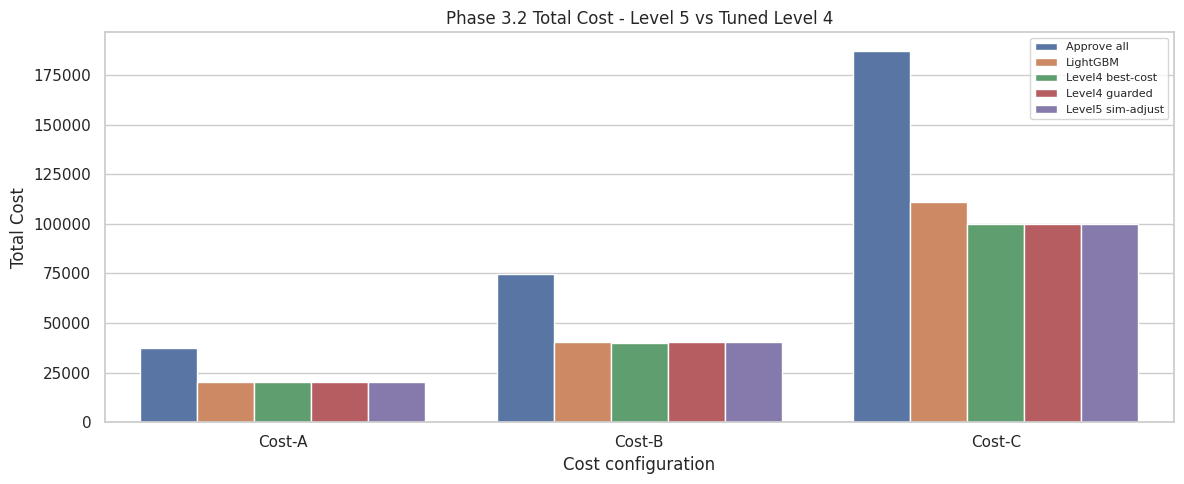

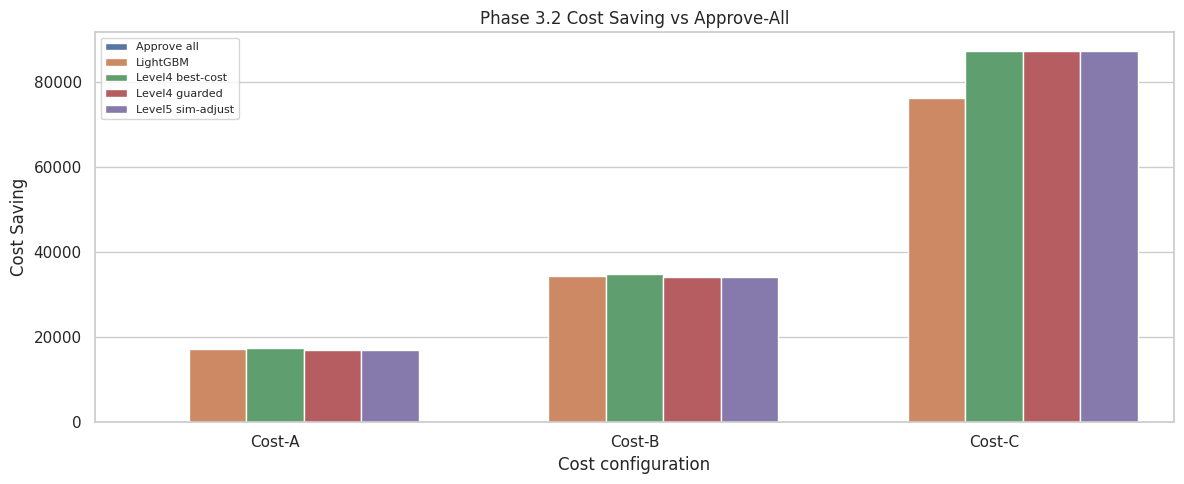

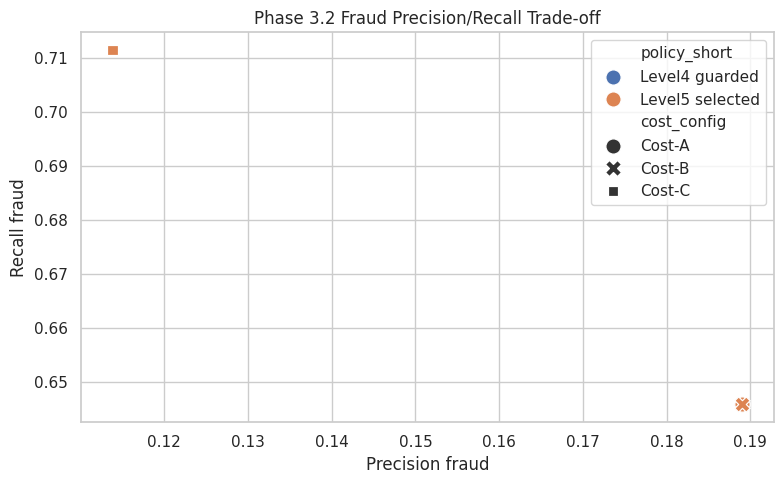

Saved Phase 3.2 outputs:
- results/phase32_hybrid_candidate_metrics_sample_100k.csv
- results/phase32_selected_policy_sample_100k.csv
- results/phase32_similarity_features_sample_100k.csv
- results/phase32_text_leakage_audit_sample_100k.csv
- results/phase32_disagreement_cases_sample_100k.csv
- results/five_level_comparison_level5_sample_100k.csv
- results/phase32_run_metadata_sample_100k.json


In [15]:
CANDIDATE_METRICS_PATH = RESULTS_DIR / f"phase32_hybrid_candidate_metrics_{RUN_OUTPUT_TAG}.csv"
SELECTED_POLICY_PATH = RESULTS_DIR / f"phase32_selected_policy_{RUN_OUTPUT_TAG}.csv"
DISAGREEMENT_PATH = RESULTS_DIR / f"phase32_disagreement_cases_{RUN_OUTPUT_TAG}.csv"
COMPARISON_PATH = RESULTS_DIR / f"five_level_comparison_level5_{RUN_OUTPUT_TAG}.csv"
METADATA_PATH = RESULTS_DIR / f"phase32_run_metadata_{RUN_OUTPUT_TAG}.json"

phase32_candidate_metrics_df.to_csv(RESULTS_DIR / "phase32_hybrid_candidate_metrics.csv", index=False)
phase32_candidate_metrics_df.to_csv(CANDIDATE_METRICS_PATH, index=False)
phase32_selected_policy_df.to_csv(RESULTS_DIR / "phase32_selected_policy.csv", index=False)
phase32_selected_policy_df.to_csv(SELECTED_POLICY_PATH, index=False)
disagreement_cases_df.to_csv(RESULTS_DIR / "phase32_disagreement_cases.csv", index=False)
disagreement_cases_df.to_csv(DISAGREEMENT_PATH, index=False)
comparison_level5_df.to_csv(RESULTS_DIR / "five_level_comparison_level5.csv", index=False)
comparison_level5_df.to_csv(COMPARISON_PATH, index=False)

plot_df = comparison_view[comparison_view["policy"].astype(str).isin(["approve_all", "lightgbm_balanced", "level4_tuned_guarded_selector", "level4_tuned_best_cost_selector", "level5_embedding_similarity_threshold_adjustment", "level5_hybrid_score_threshold"])].copy()
plot_df["policy_short"] = plot_df["policy"].astype(str).replace({"level4_tuned_guarded_selector": "Level4 guarded", "level4_tuned_best_cost_selector": "Level4 best-cost", "level5_embedding_similarity_threshold_adjustment": "Level5 sim-adjust", "level5_hybrid_score_threshold": "Level5 hybrid-score", "lightgbm_balanced": "LightGBM", "approve_all": "Approve all"})

plt.figure(figsize=(12, 5))
sns.barplot(data=plot_df, x="cost_config", y="total_cost", hue="policy_short")
plt.title("Phase 3.2 Total Cost - Level 5 vs Tuned Level 4")
plt.ylabel("Total Cost")
plt.xlabel("Cost configuration")
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"phase32_total_cost_{RUN_OUTPUT_TAG}.png", dpi=160)
plt.show()

plt.figure(figsize=(12, 5))
sns.barplot(data=plot_df, x="cost_config", y="cost_saving_vs_approve_all", hue="policy_short")
plt.title("Phase 3.2 Cost Saving vs Approve-All")
plt.ylabel("Cost Saving")
plt.xlabel("Cost configuration")
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"phase32_cost_saving_{RUN_OUTPUT_TAG}.png", dpi=160)
plt.show()

tradeoff_df = pd.concat([level4_guarded_test.assign(policy_short="Level4 guarded"), selected_test_df.assign(policy_short="Level5 selected")], ignore_index=True, sort=False)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=tradeoff_df, x="precision_fraud", y="recall_fraud", hue="policy_short", style="cost_config", s=120)
plt.title("Phase 3.2 Fraud Precision/Recall Trade-off")
plt.xlabel("Precision fraud")
plt.ylabel("Recall fraud")
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"phase32_llm_vs_dynamic_tradeoff_{RUN_OUTPUT_TAG}.png", dpi=160)
plt.show()

run_metadata = {
    "phase": "3.2", "run_mode": RUN_MODE, "sample_rows": SAMPLE_ROWS_LABEL, "project_root": str(PROJECT_ROOT),
    "selected_risk_model": SELECTED_RISK_MODEL, "level4_comparator_selector": LEVEL4_COMPARATOR_SELECTOR,
    "embedding_model_target": EMBEDDING_MODEL_NAME, "embedding_backend_used": embedding_backend, "embedding_prefix": embedding_prefix,
    "embedding_shapes": {"train": list(emb_train.shape), "validation": list(emb_validation.shape), "test": list(emb_test.shape)},
    "similarity_standardization": {"source": "train_only", "mean": sim_mean, "std": sim_std},
    "candidate_policies": ["level5_embedding_similarity_threshold_adjustment", "level5_hybrid_score_threshold"],
    "hyperparameter_grids": {"gamma_grid": GAMMA_GRID, "w_grid": W_GRID, "threshold_grid_size": int(len(THRESHOLD_GRID))},
    "leakage_controls": {"text_policy": "neutral table-to-text; no label, score, risk wording, or ProductCD interpretation", "prototype_source": "train embeddings only", "candidate_tuning": "validation only", "test_usage": "report only after selected candidate frozen", "embedding_alignment": "TransactionID checked against baseline score rows"},
    "outputs": {"candidate_metrics": str(CANDIDATE_METRICS_PATH.relative_to(PROJECT_ROOT)), "selected_policy": str(SELECTED_POLICY_PATH.relative_to(PROJECT_ROOT)), "similarity_features": str(SIMILARITY_PATH.relative_to(PROJECT_ROOT)), "text_leakage_audit": str(TEXT_AUDIT_PATH.relative_to(PROJECT_ROOT)), "disagreement_cases": str(DISAGREEMENT_PATH.relative_to(PROJECT_ROOT)), "five_level_comparison_level5": str(COMPARISON_PATH.relative_to(PROJECT_ROOT)), "figures": [str((FIGURES_DIR / f"phase32_total_cost_{RUN_OUTPUT_TAG}.png").relative_to(PROJECT_ROOT)), str((FIGURES_DIR / f"phase32_cost_saving_{RUN_OUTPUT_TAG}.png").relative_to(PROJECT_ROOT)), str((FIGURES_DIR / f"phase32_llm_vs_dynamic_tradeoff_{RUN_OUTPUT_TAG}.png").relative_to(PROJECT_ROOT))]},
    "claim_guard": "If embedding_backend_used is not minilm, do not make final LLM-assisted claim. If Level 5 does not beat tuned Level 4 on test Total Cost/Cost Saving, report honestly as LLM ablation."
}
with open(RESULTS_DIR / "phase32_run_metadata.json", "w", encoding="utf-8") as f:
    json.dump(run_metadata, f, indent=2, ensure_ascii=False)
with open(METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(run_metadata, f, indent=2, ensure_ascii=False)

print("Saved Phase 3.2 outputs:")
for path in [CANDIDATE_METRICS_PATH, SELECTED_POLICY_PATH, SIMILARITY_PATH, TEXT_AUDIT_PATH, DISAGREEMENT_PATH, COMPARISON_PATH, METADATA_PATH]:
    print("-", path.relative_to(PROJECT_ROOT))


## 13. Phase 3.2 Conclusion Template

Nếu embedding_backend_used = minilm và Level 5 giảm Total Cost hoặc tăng Cost Saving so với tuned Level 4, có thể claim MiniLM representation hỗ trợ dynamic policy trong setting đó. Nếu Level 5 không thắng Level 4, báo cáo trung thực là LLM-assisted hybrid chưa cải thiện và giữ đóng góp chính ở tuned dynamic cost-sensitive policy. Nếu backend là tfidf_svd_fallback, chỉ dùng kết quả để kiểm thử flow, không claim LLM.
